In [17]:
from langchain_qdrant import QdrantVectorStore, FastEmbedSparse
from qdrant_client import QdrantClient
from dotenv import load_dotenv
import os
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.tools import WikipediaQueryRun
from langchain_tavily import TavilySearch
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import Tool

from dataclasses import dataclass
from pydantic import BaseModel
from typing import List
from langchain_core.documents import Document

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image


In [18]:
class ProcessChainOfThought:

    def __init__(self):
        self.client = QdrantClient(
                            url=os.getenv('QDRANT_API_URL'),
                            api_key=os.getenv('QDRANT_API_KEY')
                        )
        self.dense_embedding = HuggingFaceEmbeddings(model = 'sentence-transformers/all-MiniLM-L12-v2')
        self.sparse_embedding = FastEmbedSparse(model_name ='Qdrant/bm25')
        
        self.qdrantdb = QdrantVectorStore(
            client=self.client,
            collection_name= os.getenv('COLLECTIONNAME'),
            embedding=self.dense_embedding,
            sparse_embedding=self.sparse_embedding
        )
        self.wiki_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(top_k_results= 5, doc_content_chars_max= 2000))
        self.tavily_tool = TavilySearch(
            max_results=5,
            topic="general",
        )

    @property
    def getPBIRetriver(self):

        return self.qdrantdb.as_retriever(
            search_type = 'mmr',
                search_kwarg = {
                    "k":10
                }
        )
    
    


In [19]:
llm = ChatGroq(model='openai/gpt-oss-120b')
pbi_obj = ProcessChainOfThought()
pbi_retriver = pbi_obj.getPBIRetriver


In [20]:
# @dataclass
class ChainOfCmdBot(BaseModel):

    question: str
    subQuestion : List[str] = []
    retrivedDocs : List[Document] = []
    answer: str

In [21]:
def chainOfCmdSplit(state: ChainOfCmdBot) -> ChainOfCmdBot:

    """
    Decomposes a complex user question into a sequential list of tasks using an LLM.

    This function sends the initial question to a large language model (LLM)
    with a specific prompt instructing it to break down the overall goal into
    smaller, manageable three to four sub-tasks. This is a form of 'chain-of-thought'
    or 'prompt chaining' designed to improve the accuracy and traceability
    of the final answer by addressing one aspect of the problem at a time.

    :param state: object of ChainOfCmdBot include below members.
                    a. question (String)
                    b. subQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
    :type: ChainOfCmdBot
                    
    :returns: object of ChainOfCmdBot with Modified Value of attributes subQuestion.

    Raises:
        APIError: If the LLM API call fails or returns an error.
        ValueError: If the model_config is invalid or missing required keys.
    """

    prompt = f""" 
                Decomposes a complex user question into a sequential list of tasks using an LLM. Split the Complex Question into 3 to 4 sub task. 
                Use Function Docstring to get more details.
                Question: {state.question}

                Example:
                Question: "What is Power BI"
                subQuestion:
                    1. Define Power BI?
                    2. Define Power BI Components?
                    3. Define Power BI Usage?
                Please add Questions only in subQuestion List not other details.
            """
    
    result = llm.invoke(prompt)
    questions = [qus for qus in result.content.split("\n") if qus.strip()]
    return state.model_copy(update={"subQuestion" : questions})
    
    

In [22]:
def documentRetriver(state: ChainOfCmdBot) -> ChainOfCmdBot:
    """Extracts relevant documents based on the sub-questions of a Chain of Command query.

        This node leverages a Language Model (LLM) to intelligently analyze a set of
        "Chain of Command" sub-questions (e.g., 'What is Span of Control?') and retrieve
        the most pertinent documents from a knowledge base that contain the answers or
        required context for generating a final answer.

        :param state: Object of ChainOfCmdBot having below 4 attributes
                    a. question (String)
                    b. subQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
        :type: ChainOfCmdBot
                    
        :returns: object of ChainOfCmdBot with updated retrivedDocs attributes.
                A consolidated list of unique, highly relevant documents extracted
                from the `knowledge_base`. Documents are typically scored or selected
                based on their relevance to the combined sub-questions.
    """

    docs = []
    for qus in state.subQuestion:
        docset = pbi_retriver.invoke(qus)
        docs.extend(docset)

    return state.model_copy(update={"retrivedDocs": docs})

In [23]:
def generateAnswer(state: ChainOfCmdBot) -> ChainOfCmdBot:

    """ 
    Synthesizes the final answer by consolidating retrieved documents.

    This terminal node in the LLM chain takes the list of relevant documents, 
    feeds them into the Language Model (LLM) as context, and prompts the LLM to generate a single, coherent, and
    comprehensive answer that addresses all parts of the original query.

    :param state: Object of ChainOfCmdBot having below 4 attributes
                    a. question (String)
                    b. subQuestion (List of String)
                    c. retrivedDocs (List of Document)
                    d. answer (string)
    :type: ChainOfCmdBot
                    
    :returns: object of ChainOfCmdBot with updated answer based on retrivedDocs attributes.
                The final, comprehensive answer string generated by the LLM, grounded
                in the provided documents and addressing the user's original query.
    """

    context_documents = '\n\n'.join([doc.page_content for doc in state.retrivedDocs])
    prompt = f""" 
                You are an expert Q&A system. Your task is to generate a single, comprehensive, and well-structured answer to the user's original query.

                    **Instructions:**
                    1.  Read the **Original Query** and the intermediate **Sub-Questions**.
                    2.  Carefully analyze the content of the **Context Documents** provided below.
                    3.  Synthesize the information from the documents to construct a complete answer that addresses all parts of the Original Query.
                    4.  Do not introduce any information that is not explicitly present in the Context Documents.
                    5.  Structure your final answer clearly using markdown headings and bullet points where appropriate.

                    **Original Query:**
                    {state.question}

                    **Sub-Questions (for context on intent):**
                    {state.subQuestion}

                    **Context Documents:**
                    {context_documents}

                    **Final Answer:**
            """
    
    result = llm.invoke(prompt).content
    
    return state.model_copy(update={"answer": result})
    
    
    

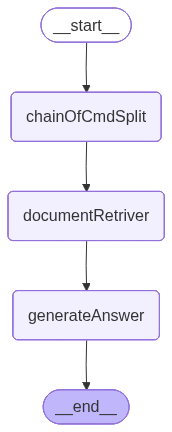

In [24]:
graph = StateGraph(ChainOfCmdBot)

graph.add_node("chainOfCmdSplit", chainOfCmdSplit)
graph.add_node("documentRetriver", documentRetriver)
graph.add_node("generateAnswer", generateAnswer)

graph.add_edge(START, "chainOfCmdSplit")
graph.add_edge("chainOfCmdSplit", "documentRetriver")
graph.add_edge("documentRetriver", "generateAnswer")
graph.add_edge("generateAnswer", END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))


In [29]:
if __name__ == "__main__":
    query = "What is Pagenated Report and how it is different from Power BI Desktop"
    state = ChainOfCmdBot(question=query, subQuestion = [],     retrivedDocs = [],     answer = "")
    final = graph_builder.invoke(state)

    print(final['question'])
    print('--------------------------------')
    print(final['subQuestion'])
    print('--------------------------------')
    print(final['answer'])
    print('--------------------------------')
 



What is Pagenated Report and how it is different from Power BI Desktop
--------------------------------
['subQuestion:', '1. What is a paginated report?', '2. What are the main features and use cases of paginated reports?', '3. What is Power\u202fBI Desktop and what are its core capabilities?', '4. How do paginated reports differ from Power\u202fBI Desktop in terms of design, rendering, and intended scenarios?']
--------------------------------
## 1. What is a Paginated Report?

- **Also called “perfect‑pixel” reports** – the layout is fixed so that every element appears at exactly the same position on the page.  
- **Designed to fit on a page** and to handle large tables that can span many pages (hence *paginated*).  
- **Static, fixed‑layout** – the visual appearance does not change based on user interaction.  
- **Optimized for printing and export** to PDF, Word, or other paged formats.  
- **Typical use‑cases**  
  - Operational reporting (e.g., daily sales summaries)  
  - Invoice